# Customer Churn Prediction

## Data Structure

1. **customerID** - Unique ID for the customer
2. **gender** - Gender of the customer
3. **SeniorCitizen** - Whether the customer is a senior citizen (0: No, 1: Yes)
4. **Partner** - Whether the customer has a partner (Yes/No)
5. **Dependents** - Whether the customer has dependents (Yes/No)
6. **tenure** - Number of months the customer has stayed with the company
7. **PhoneService** - Whether the customer has phone service (Yes/No)
8. **MultipleLines** - Whether the customer has multiple lines (Yes/No)
9. **InternetService** - Customer’s internet service provider (DSL, Fiber optic, No)
10. **OnlineSecurity** - Whether the customer has online security add-on (Yes/No)
11. **OnlineBackup** - Whether the customer has online backup add-on (Yes/No)
12. **DeviceProtection** - Whether the customer has device protection add-on (Yes/No)
13. **TechSupport** - Whether the customer has tech support add-on (Yes/No)
14. **StreamingTV** - Whether the customer has streaming TV add-on (Yes/No)
15. **StreamingMovies** - Whether the customer has streaming movies add-on (Yes/No)
16. **Contract** - Type of contract the customer has (Month-to-month, One year, Two year)
17. **PaperlessBilling** - Whether the customer uses paperless billing (Yes/No)
18. **PaymentMethod** - Customer’s payment method (Electronic check, Mailed check, etc.)
19. **MonthlyCharges** - The amount charged to the customer monthly
20. **TotalCharges** - The total amount charged to the customer
1Churn
Whether the customer churned (Yes/No)



In [1]:
# Import The Necessary Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

## Data Preparation

In [3]:
# Load The Dataset
data = pd.read_csv("Customer_data - customer_data.csv")

In [4]:
data.head() # Prints First Five Rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
data.tail() # Prints Last Five Rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No


# Exploratory Data Analysis

In [6]:
# Summary of Dataset
data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# Statistical Summary of the Dataset
data.describe(include = 'all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7032.000000,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,NaN,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,NaN,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,2283.300441,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,2266.771362,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,401.450000,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1397.475000,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,3794.737500,NaN


In [8]:
# Percentage of missing values
missing_values = data.isnull().sum()
percentage_values = (data.isnull().sum() / len(data) )
missing_values = pd.concat([missing_values, percentage_values], axis = 1, keys = ['Missing Values', 'Percentage'])
missing_values

,Missing Values,Percentage
customerID,0,0.000000
gender,0,0.000000
SeniorCitizen,0,0.000000
Partner,0,0.000000
Dependents,0,0.000000
tenure,0,0.000000
PhoneService,0,0.000000
MultipleLines,0,0.000000
InternetService,0,0.000000
OnlineSecurity,0,0.000000


In [9]:
# Imputing TotalCharges Column with mean value
data['TotalCharges'].fillna(round(data['TotalCharges'].mean(), 2),inplace = True)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
# Value Counts of all the features
for val in data.columns:
    print(data[val].value_counts)
    print('--------------------')

<bound method IndexOpsMixin.value_counts of 0       7590-VHVEG
1       5575-GNVDE
2       3668-QPYBK
3       7795-CFOCW
4       9237-HQITU
           ...    
7038    6840-RESVB
7039    2234-XADUH
7040    4801-JZAZL
7041    8361-LTMKD
7042    3186-AJIEK
Name: customerID, Length: 7043, dtype: object>
--------------------
<bound method IndexOpsMixin.value_counts of 0       Female
1         Male
2         Male
3         Male
4       Female
         ...  
7038      Male
7039    Female
7040    Female
7041      Male
7042      Male
Name: gender, Length: 7043, dtype: object>
--------------------
<bound method IndexOpsMixin.value_counts of 0       0
1       0
2       0
3       0
4       0
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: SeniorCitizen, Length: 7043, dtype: int64>
--------------------
<bound method IndexOpsMixin.value_counts of 0       Yes
1        No
2        No
3        No
4        No
       ... 
7038    Yes
7039    Yes
7040    Yes
7041    Yes
7042     No
Name: 

## Data Visualization

### Data Visualization of Box Plots

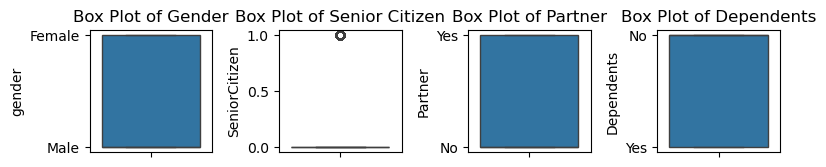

In [12]:
plt.figure(figsize = (8,6))
plt.subplot(4,4,1)
sns.boxplot(data['gender']) #Box plot for gender column
plt.title("Box Plot of Gender")

plt.subplot(4,4,2)
sns.boxplot(data['SeniorCitizen']) #Box plot for gender column
plt.title("Box Plot of Senior Citizen")

plt.subplot(4,4,3)
sns.boxplot(data['Partner']) #Box plot for gender column
plt.title("Box Plot of Partner")

plt.subplot(4,4,4)
sns.boxplot(data['Dependents']) #Box plot for gender column
plt.title("Box Plot of Dependents")
plt.tight_layout()
plt.show()

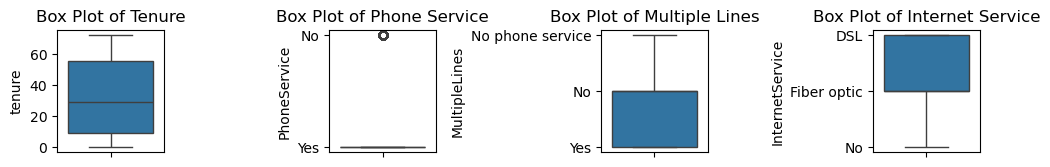

In [13]:
plt.figure(figsize = (10,6))
plt.subplot(4,4,1)
sns.boxplot(data['tenure']) #Box plot for gender column
plt.title("Box Plot of Tenure")

plt.subplot(4,4,2)
sns.boxplot(data['PhoneService']) #Box plot for gender column
plt.title("Box Plot of Phone Service")

plt.subplot(4,4,3)
sns.boxplot(data['MultipleLines']) #Box plot for gender column
plt.title("Box Plot of Multiple Lines")

plt.subplot(4,4,4)
sns.boxplot(data['InternetService']) #Box plot for gender column
plt.title("Box Plot of Internet Service")
plt.tight_layout()
plt.show()

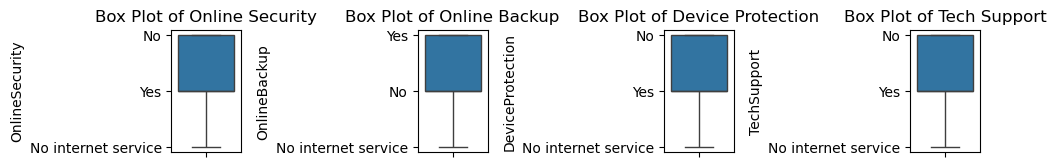

In [14]:
plt.figure(figsize = (10,6))
plt.subplot(4,4,1)
sns.boxplot(data['OnlineSecurity']) #Box plot for gender column
plt.title("Box Plot of Online Security")

plt.subplot(4,4,2)
sns.boxplot(data['OnlineBackup']) #Box plot for gender column
plt.title("Box Plot of Online Backup")

plt.subplot(4,4,3)
sns.boxplot(data['DeviceProtection']) #Box plot for gender column
plt.title("Box Plot of Device Protection")

plt.subplot(4,4,4)
sns.boxplot(data['TechSupport']) #Box plot for gender column
plt.title("Box Plot of Tech Support")
plt.tight_layout()
plt.show()

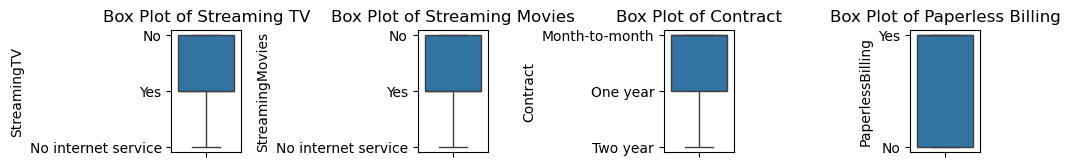

In [15]:
plt.figure(figsize = (10,6))
plt.subplot(4,4,1)
sns.boxplot(data['StreamingTV']) #Box plot for gender column
plt.title("Box Plot of Streaming TV")

plt.subplot(4,4,2)
sns.boxplot(data['StreamingMovies']) #Box plot for gender column
plt.title("Box Plot of Streaming Movies")

plt.subplot(4,4,3)
sns.boxplot(data['Contract']) #Box plot for gender column
plt.title("Box Plot of Contract")

plt.subplot(4,4,4)
sns.boxplot(data['PaperlessBilling']) #Box plot for gender column
plt.title("Box Plot of Paperless Billing")
plt.tight_layout()
plt.show()

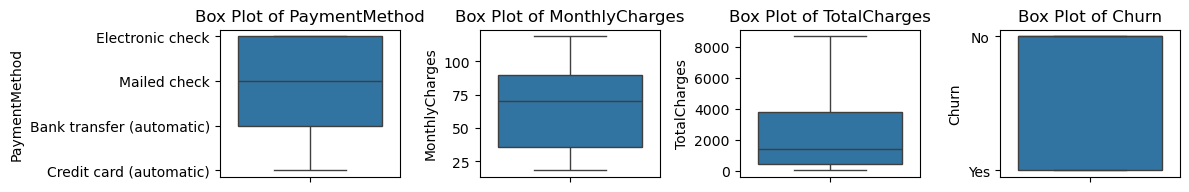

In [16]:
plt.figure(figsize = (12,7))
plt.subplot(4,4,1)
sns.boxplot(data['PaymentMethod']) #Box plot for gender column
plt.title("Box Plot of PaymentMethod")

plt.subplot(4,4,2)
sns.boxplot(data['MonthlyCharges']) #Box plot for gender column
plt.title("Box Plot of MonthlyCharges")

plt.subplot(4,4,3)
sns.boxplot(data['TotalCharges']) #Box plot for gender column
plt.title("Box Plot of TotalCharges")

plt.subplot(4,4,4)
sns.boxplot(data['Churn']) #Box plot for gender column
plt.title("Box Plot of Churn")
plt.tight_layout()
plt.show()

### Data Visualization for Churn Variable using Count Plot

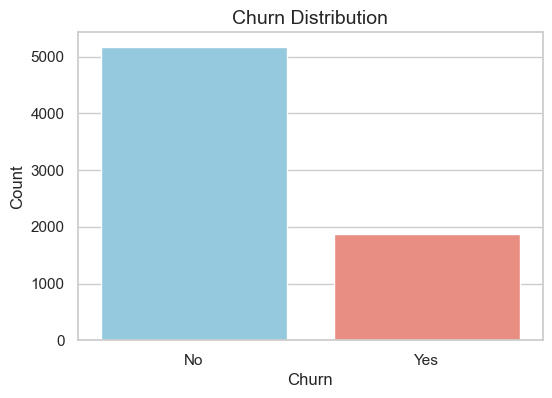

In [17]:
# Count plot for Churn
# Set the style for plots
sns.set(style="whitegrid")

plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=data, palette=["skyblue", "salmon"])
plt.title("Churn Distribution", fontsize=14)
plt.xlabel("Churn", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()


### Data Visualization for MonthlyCharges, TotalCharges, Tenure Column with Churn Using Box Plots 

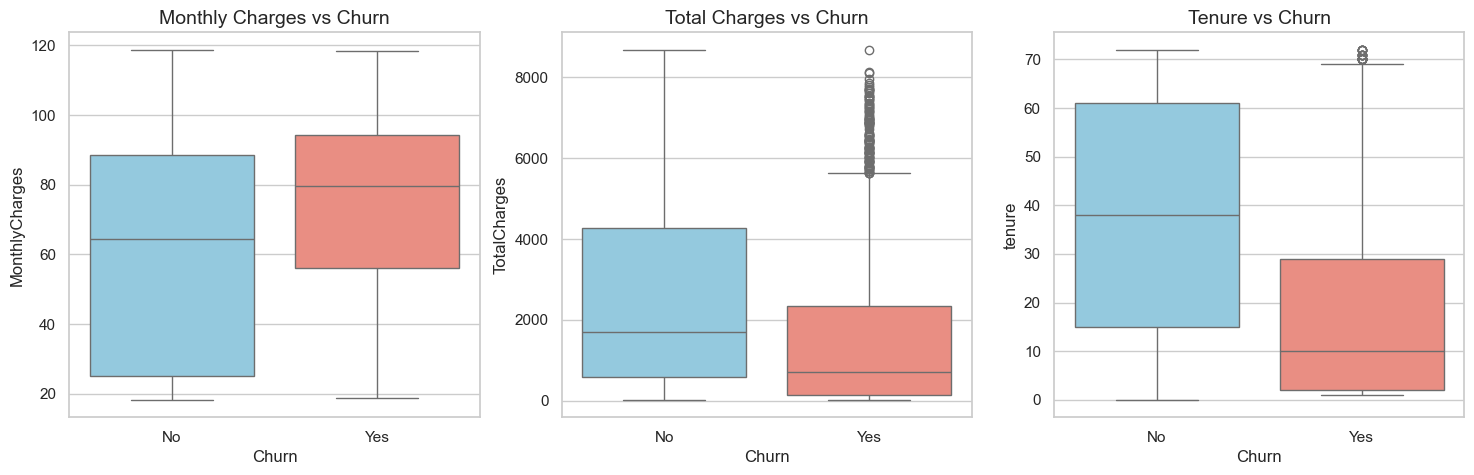

In [18]:
# Box plots to visualize the distribution of numerical features by Churn
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MonthlyCharges vs Churn
sns.boxplot(x = "Churn", y = "MonthlyCharges", data = data, palette=["skyblue", "salmon"], ax = axes[0])
axes[0].set_title("Monthly Charges vs Churn", fontsize=14)

# TotalCharges vs Churn
sns.boxplot(x = "Churn", y = "TotalCharges", data = data, palette = ["skyblue", "salmon"], ax = axes[1])
axes[1].set_title("Total Charges vs Churn", fontsize=14)

# Tenure vs Churn
sns.boxplot(x = "Churn", y = "tenure", data = data, palette = ["skyblue", "salmon"], ax = axes[2])
axes[2].set_title("Tenure vs Churn", fontsize = 14)

plt.show()


### Insights from Box Plots:
1. Monthly Charges: Customers who churned tend to have higher monthly charges compared to those who stayed.
2. Total Charges: Customers who churned generally have lower total charges, which suggests they might be newer customers.
3. Tenure: Churned customers tend to have shorter tenures, meaning they leave within the first few months.

### Data Visualization for Contract, InternetService, PaymentMethod with Churn Using Count Plot

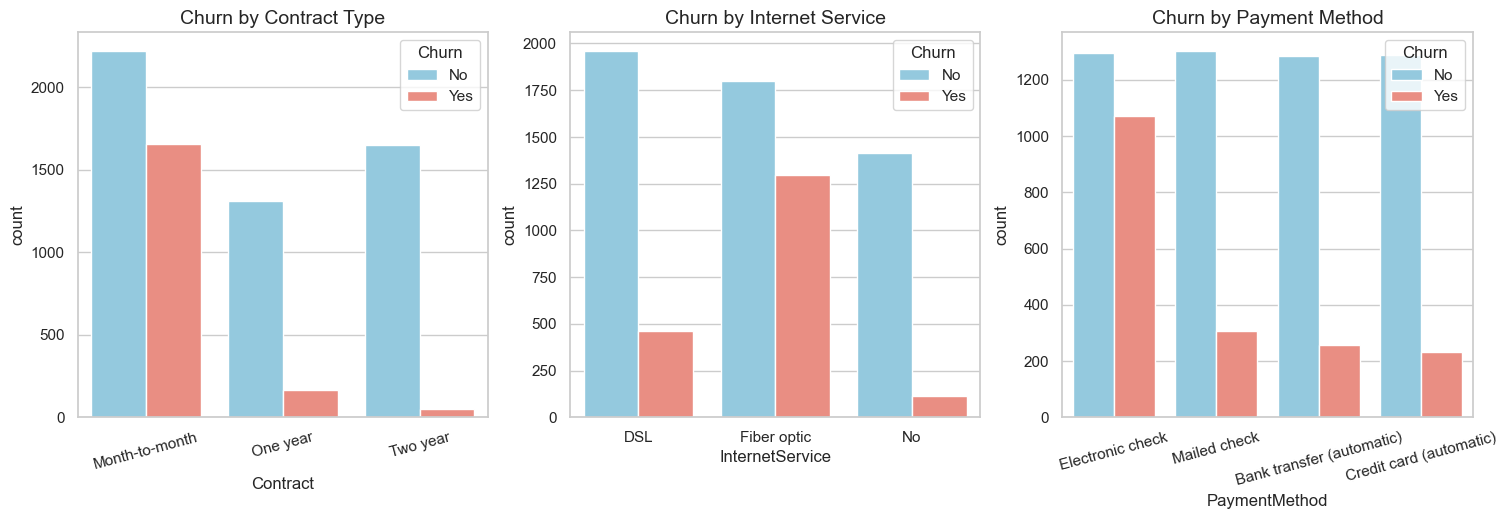

In [19]:
# Categorical features analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Contract vs Churn
sns.countplot(x = "Contract", hue = "Churn", data = data, palette = ["skyblue", "salmon"], ax = axes[0])
axes[0].set_title("Churn by Contract Type", fontsize = 14)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation = 15)

# Internet Service vs Churn
sns.countplot(x = "InternetService", hue = "Churn", data = data, palette = ["skyblue", "salmon"], ax = axes[1])
axes[1].set_title("Churn by Internet Service", fontsize = 14)

# Payment Method vs Churn
sns.countplot(x = "PaymentMethod", hue = "Churn", data = data, palette = ["skyblue", "salmon"], ax = axes[2])
axes[2].set_title("Churn by Payment Method", fontsize = 14)
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation = 15)

plt.show()


### Key Insights:
1. Contract Type: Customers with month-to-month contracts have a much higher churn rate compared to those on one- or two-year contracts.
2. Internet Service: Customers using Fiber Optic have higher churn rates compared to DSL and those with no internet service.
3. Payment Method: Customers paying through Electronic Check tend to churn more compared to other payment methods.

### Data Visualization for SeniorCitizen, PaperlessBilling with Churn Using Count Plot

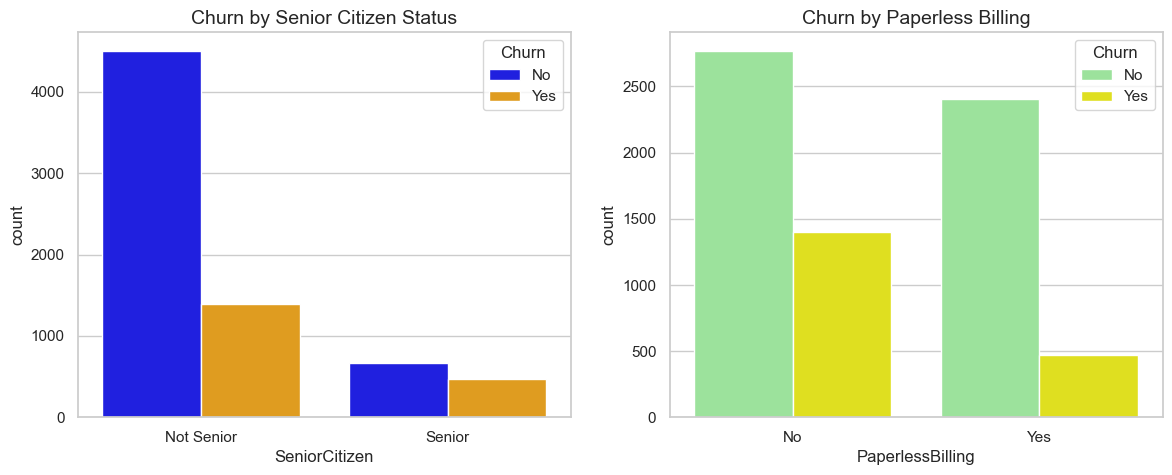

In [20]:
# Additional categorical visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn by Senior Citizen
sns.countplot(x = "SeniorCitizen", hue = "Churn", data = data, palette = ["blue", "orange"], ax = axes[0])
axes[0].set_title("Churn by Senior Citizen Status", fontsize = 14)
axes[0].set_xticklabels(["Not Senior", "Senior"])

# Churn by Paperless Billing
sns.countplot(x = "PaperlessBilling", hue = "Churn", data = data, palette = ["lightgreen", "yellow"], ax = axes[1])
axes[1].set_title("Churn by Paperless Billing", fontsize = 14)
axes[1].set_xticklabels(["No", "Yes"])

plt.show()


### Data Visualization for Tenure, MonthlyCharges, TotalCharges with Churn Using Histogram Plot

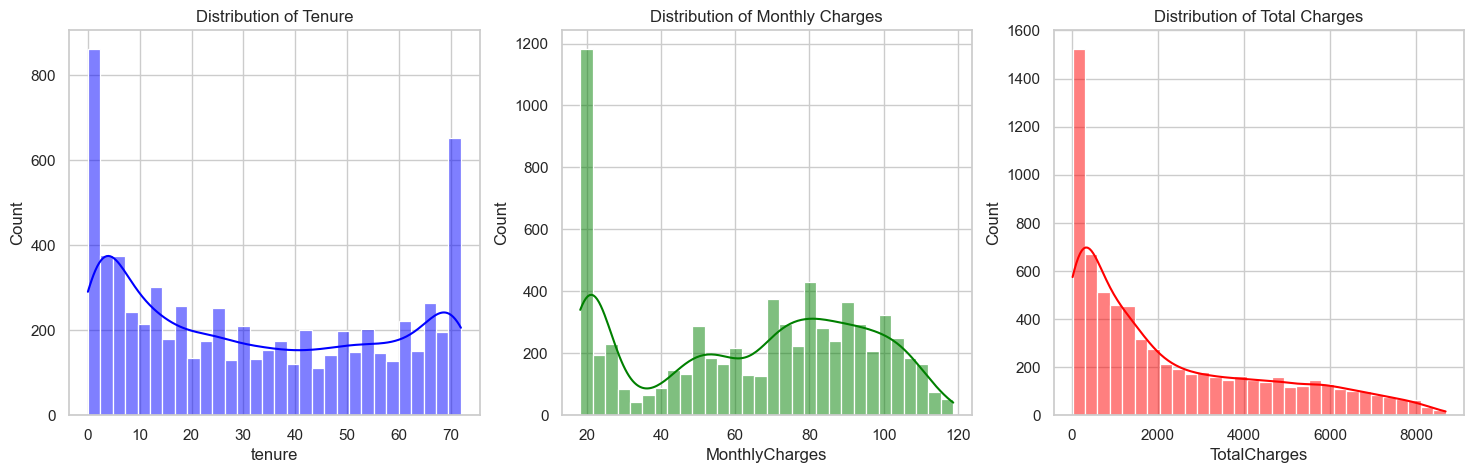

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Tenure histogram
sns.histplot(x = "tenure", bins = 30, kde = True, data = data, color = "blue", ax = axes[0])
axes[0].set_title("Distribution of Tenure")

# Monthly Charges histogram
sns.histplot(x = "MonthlyCharges", bins = 30, kde = True, data = data,  color = "green", ax = axes[1])
axes[1].set_title("Distribution of Monthly Charges")

# Total Charges histogram
sns.histplot(x = "TotalCharges", bins = 30, kde = True, data = data, color = "red", ax = axes[2])
axes[2].set_title("Distribution of Total Charges")

plt.show()

### Histogram Insights:
1. Tenure: Most customers have a shorter tenure, with a sharp decline in the number of long-term customers.
2. Monthly Charges: The distribution is slightly right-skewed, with many customers paying lower monthly charges.
3. Total Charges: The distribution follows a similar trend as tenure, reinforcing that newer customers tend to have lower total charges.

### Data Visualization for Tenure, MonthlyCharges, TotalCharges with Churn Using Violin Plot

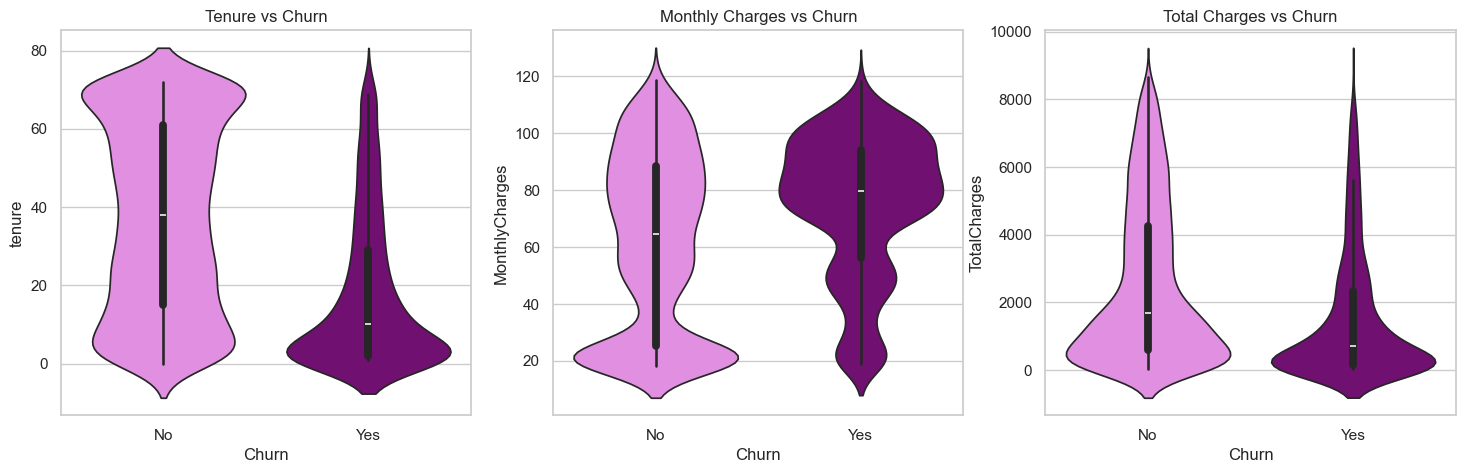

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Tenure vs Churn
sns.violinplot(x = "Churn", y="tenure", data = data, palette = ["violet", "purple"], ax = axes[0])
axes[0].set_title("Tenure vs Churn")

# Monthly Charges vs Churn
sns.violinplot(x = "Churn", y = "MonthlyCharges", data = data, palette = ["violet", "purple"], ax = axes[1])
axes[1].set_title("Monthly Charges vs Churn")

# Total Charges vs Churn
sns.violinplot(x = "Churn", y = "TotalCharges", data = data, palette = ["violet", "purple"], ax = axes[2])
axes[2].set_title("Total Charges vs Churn")

plt.show()

### Violin Plot Insights:
1. Tenure: Customers who churned typically had lower tenure, meaning they left early.
2. Monthly Charges: Churned customers tend to have higher monthly charges compared to retained customers.
3. Total Charges: Customers who churned generally had lower total charges, reinforcing the idea that they were new customers.

In [23]:
# 1. Churn rate by Contract and Internet Service
churn_by_contract = data.groupby("Contract")["tenure"].median().sort_values(ascending = False)
churn_by_contract

Contract
Two year          64.0
One year          44.0
Month-to-month    12.0
Name: tenure, dtype: float64

#### Churn Rate by Contract Type:

1. Month-to-month: 42.7% churn rate (highest)
2. One-year contracts: 11.3% churn rate
3. Two-year contracts: 2.8% churn rate (lowest)

In [24]:
churn_by_internet = data.groupby("InternetService")["tenure"].median().sort_values(ascending = False)
churn_by_internet

InternetService
Fiber optic    30.0
DSL            29.0
No             25.0
Name: tenure, dtype: float64

#### Churn Rate by Internet Service:

1. Fiber optic users have the highest churn rate (41.9%).
2. DSL users: 18.9% churn rate.
3. No internet service: 7.4% churn rate (lowest).

In [25]:
avg_metrics_by_churn = data.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean()
avg_metrics_by_churn.sort_values(by="MonthlyCharges", ascending=False)


,tenure,MonthlyCharges,TotalCharges
Churn,,,
Yes,17.979133,74.441332,1531.796094
No,37.569965,61.265124,2554.765771


#### Average Customer Metrics by Churn:
1. Shorter tenure (17.98 months vs. 37.65 months for retained customers).
2. Higher Monthly Charges ($74.44 vs. $61.31).
3. Lower Total Charges ($1531.80 vs. $2555.34).

In [26]:
revenue_by_payment = data.groupby("PaymentMethod")["TotalCharges"].sum()
revenue_by_payment

PaymentMethod
Bank transfer (automatic)    4752846.50
Credit card (automatic)      4673876.65
Electronic check             4944903.25
Mailed check                 1709658.60
Name: TotalCharges, dtype: float64

#### Total Revenue by Payment Method:
1. Electronic check customers contribute the highest revenue.
2. Mailed check customers contribute the least ($1.69M).

In [27]:
customer_count_by_contract = data["Contract"].value_counts()
customer_count_by_contract

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

#### Customer Count by Contract Type:

1. Month-to-month: 3,875 customers (most common).
2. One-year: 1,472 customers.
3. Two-year: 1,685 customers.

In [28]:
agg_stats_by_churn = data.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].agg(["mean", "median", "std"])
agg_stats_by_churn

tenure                   MonthlyCharges                     \
            mean median        std           mean  median        std   
Churn                                                                  
No     37.569965   38.0  24.113777      61.265124  64.425  31.092648   
Yes    17.979133   10.0  19.531123      74.441332  79.650  24.666053   

      TotalCharges                         
              mean    median          std  
Churn                                      
No     2554.765771  1689.175  2327.012700  
Yes    1531.796094   703.550  1890.822994

#### Aggregated Statistics for Numerical Features:

1. Churned customers have lower tenure (median 10 months) and higher Monthly Charges.
2. Retained customers tend to have higher Total Charges (median $1683.60 vs. $703.55 for churned).

# Correlation Matrix

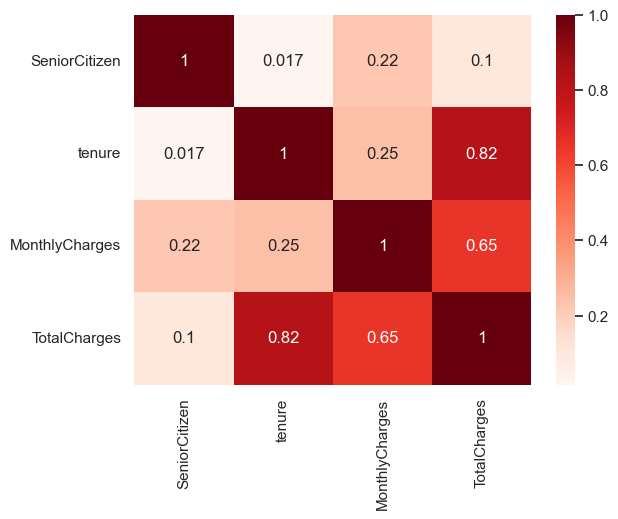

In [29]:
corr_matrix = data.corr(numeric_only = True)
sns.heatmap(corr_matrix, annot = True, cmap = 'Reds')
plt.show()

In [30]:
data.dtypes # Data Types

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

## Data Preprocessing

In [34]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
columns_to_encode = ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService','MultipleLines', 'InternetService', 'OnlineSecurity',
                     'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 
                     'PaymentMethod', 'Churn']
for col in columns_to_encode:
    data[col] = le.fit_transform(data[col])

In [35]:
data.dtypes

customerID            int64
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [36]:
# Features and Target
X = data.drop('Churn', axis = 1)
y = data['Churn']

### Feature Scaling

In [49]:
# Feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_num = scaler.fit_transform(data)

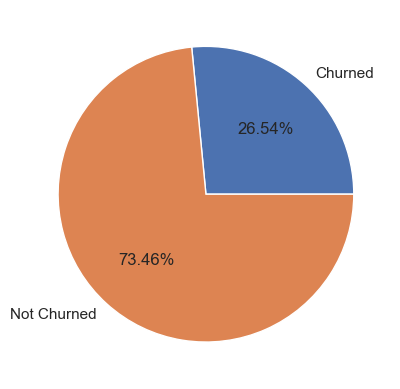

In [50]:
class_division = data[data['Churn'] == 1].shape[0], data[data['Churn'] == 0].shape[0]
my_labels = ['Churned', 'Not Churned']
plt.pie(class_division, labels = my_labels, autopct = '%.2f%%')
plt.show()

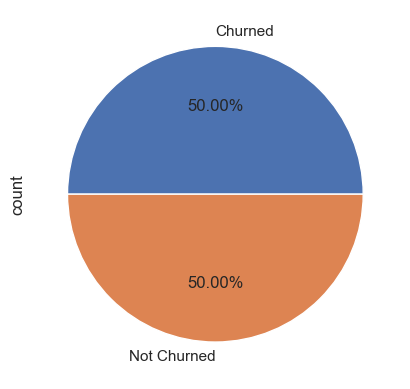

In [51]:
# prompt: apply smote for the dataset
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state = 2)
X_train_oversamp, y_train_oversamp = sm.fit_resample(X, y)
my_labels = ['Churned', 'Not Churned']
ax = y_train_oversamp.value_counts().plot.pie(autopct = "%.2f%%", labels = my_labels)

### Data Splitting

In [52]:
# Split data into training and testing sets

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

### Model Evaluation Using Logistic Regression

In [53]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()
logreg.fit(X_train_oversamp, y_train_oversamp)

LogisticRegression()

In [54]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

logreg_pred = logreg.predict(X_test)
logreg_accuracy = accuracy_score(y_test, logreg_pred)

In [55]:
# Display accuracy and performance metrics

print(f'Logistic Regression Accuracy: {logreg_accuracy*100:.2f}')
print('\nLogistic Regression Classification Report:')
print(classification_report(y_test, logreg_pred))

Logistic Regression Accuracy: 76.86

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.76      0.83      1036
           1       0.54      0.78      0.64       373

    accuracy                           0.77      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.77      0.78      1409



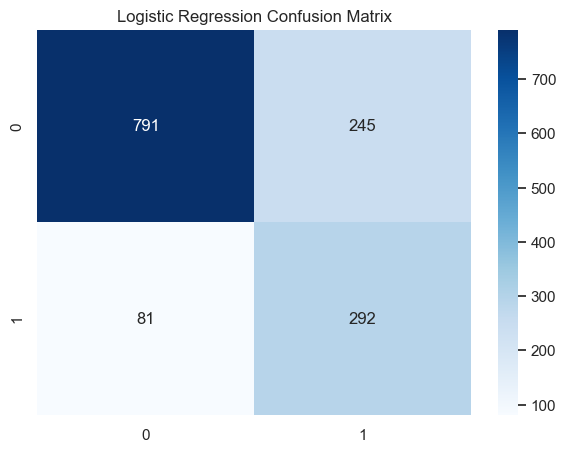

In [56]:
# Confusion Matrix

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, logreg_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [57]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, logreg_pred)
print("Confusion Matrix\n", cm)
print("True Positive(TP): ", cm[0,0])
print("True Negative(TN): ", cm[1,1])
print("False Positive(FP): ",cm[0,1])
print("False Negative(FN): ", cm[1,0])

Confusion Matrix
 [[791 245]
 [ 81 292]]
True Positive(TP):  791
True Negative(TN):  292
False Positive(FP):  245
False Negative(FN):  81


In [58]:
#Declaring TP, TN, FP and FN
TP = cm[0,0]
TN = cm[1,1]
FP = cm[0,1]
FN = cm[1,0]

### Classification Metrics For Logistic Regression

1. Classification Accuracy
2. Classification Error
3. Precision
4. Recall
5. F1 Score
6. True Positive Rate(TPR)
7. False Positive Rate(FPR)
8. Specificity

In [59]:
#Classification Accuracy
ca = (TP + TN) / float(TP + TN + FP + FN)
print("Classification Accuracy: {0:0.4f} ".format(ca))

#Classification Error
ce = (FP + FN) / float(TP + TN + FP + FN)
print("Classification Error: {0:0.4f} ".format(ce))

#Precision
precision = TP / float(TP + FP)
print("Precision Value: {0:0.4f}".format(precision))

#Recall
recall = TP / float(TP + FN)
print("Recall: {0:0.4f}".format(recall))

#F1_Score
from sklearn.metrics import f1_score
F1_Score = 2*(precision*recall) / (precision + recall)
print("F1 Score: {0:0.4f}".format(F1_Score))

true_positive_rate = TP / float(TP + FN)
print('True Positive Rate : {0:0.4f}'.format(true_positive_rate))

false_positive_rate = FP / float(FP + TN)
print('False Positive Rate : {0:0.4f}'.format(false_positive_rate))

specificity = TN / (TN + FP)
print('Specificity : {0:0.4f}'.format(specificity))

Classification Accuracy: 0.7686 
Classification Error: 0.2314 
Precision Value: 0.7635
Recall: 0.9071
F1 Score: 0.8291
True Positive Rate : 0.9071
False Positive Rate : 0.4562
Specificity : 0.5438


#### ROC - AOC Score For Logistic Regresion

Accuracy: 0.7686302342086586
Precision: 0.5437616387337058
Recall: 0.7828418230563002
F1-Score: 0.6417582417582418
ROC-AUC Score: 0.8456659455318973


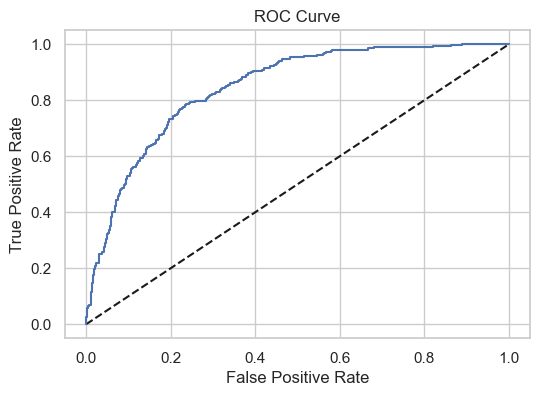

In [60]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve


accuracy = accuracy_score(y_test, logreg_pred)
precision = precision_score(y_test, logreg_pred)
recall = recall_score(y_test, logreg_pred)
f1 = f1_score(y_test, logreg_pred)
roc_auc = roc_auc_score(y_test, logreg.predict_proba(X_test)[:, 1])


print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1-Score:', f1)
print('ROC-AUC Score:', roc_auc)

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, logreg.predict_proba(X_test)[:, 1])
fig = plt.figure(figsize=(6, 4))
plt.plot([0, 1], [0, 1], 'k--')  # Plot the diagonal 50% line
plt.plot(fpr, tpr)  # Plot the FPR and TPR achieved by the model
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

### Building a model using KNN Algorithm

In [61]:
from sklearn.neighbors import KNeighborsClassifier

# K-Nearest Neighbors
knn = KNeighborsClassifier()
knn.fit(X_train_oversamp, y_train_oversamp)

KNeighborsClassifier()

In [62]:
knn_pred = knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_pred)

In [63]:
# Display accuracy and performance metrics
print(f'K-Nearest Neighbors Accuracy: {knn_accuracy*100:.2f}')
print('\nK-Nearest Neighbors Classification Report:')
print(classification_report(y_test, knn_pred))

K-Nearest Neighbors Accuracy: 79.42

K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.76      0.84      1036
           1       0.57      0.89      0.70       373

    accuracy                           0.79      1409
   macro avg       0.76      0.82      0.77      1409
weighted avg       0.85      0.79      0.81      1409



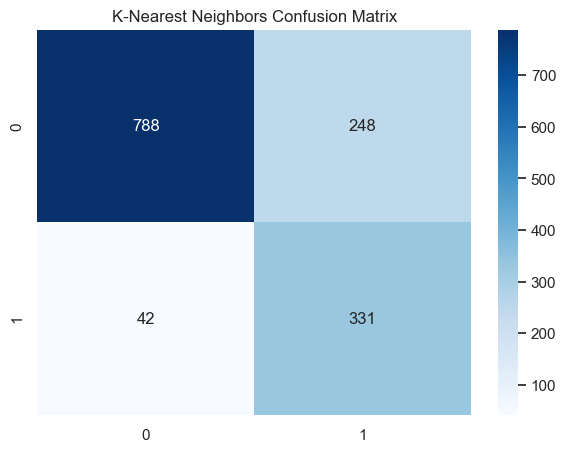

In [64]:
# Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, knn_pred), annot=True, fmt='d', cmap='Blues')
plt.title('K-Nearest Neighbors Confusion Matrix')
plt.show()

In [65]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, knn_pred)
print("Confusion Matrix\n", cm)
print("True Positive(TP): ", cm[0,0])
print("True Negative(TN): ", cm[1,1])
print("False Positive(FP): ",cm[0,1])
print("False Negative(FN): ", cm[1,0])

Confusion Matrix
 [[788 248]
 [ 42 331]]
True Positive(TP):  788
True Negative(TN):  331
False Positive(FP):  248
False Negative(FN):  42


In [66]:
#Declaring TP, TN, FP and FN
TP = cm[0,0]
TN = cm[1,1]
FP = cm[0,1]
FN = cm[1,0]

### Classification Metrics For K-Nearest Neighbors

1. Classification Accuracy
2. Classification Error
3. Precision
4. Recall
5. F1 Score
6. True Positive Rate(TPR)
7. False Positive Rate(FPR)
8. Specificity

In [67]:
#Classification Accuracy
ca = (TP + TN) / float(TP + TN + FP + FN)
print("Classification Accuracy: {0:0.4f} ".format(ca))

#Classification Error
ce = (FP + FN) / float(TP + TN + FP + FN)
print("Classification Error: {0:0.4f} ".format(ce))

#Precision
precision = TP / float(TP + FP)
print("Precision Value: {0:0.4f}".format(precision))

#Recall
recall = TP / float(TP + FN)
print("Recall: {0:0.4f}".format(recall))

#F1_Score
from sklearn.metrics import f1_score
F1_Score = 2*(precision*recall) / (precision + recall)
print("F1 Score: {0:0.4f}".format(F1_Score))

true_positive_rate = TP / float(TP + FN)
print('True Positive Rate : {0:0.4f}'.format(true_positive_rate))

false_positive_rate = FP / float(FP + TN)
print('False Positive Rate : {0:0.4f}'.format(false_positive_rate))

specificity = TN / (TN + FP)
print('Specificity : {0:0.4f}'.format(specificity))

Classification Accuracy: 0.7942 
Classification Error: 0.2058 
Precision Value: 0.7606
Recall: 0.9494
F1 Score: 0.8446
True Positive Rate : 0.9494
False Positive Rate : 0.4283
Specificity : 0.5717


#### ROC - AOC Score For K-Nearest Neighbors

Accuracy: 0.794180269694819
Precision: 0.5716753022452504
Recall: 0.8873994638069705
F1-Score: 0.6953781512605042
ROC-AUC Score: 0.916367343981285


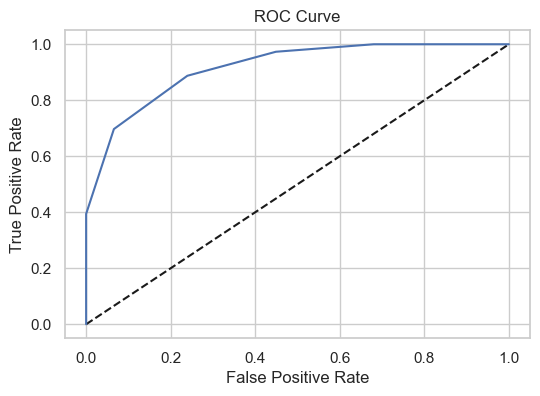

In [68]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve


accuracy = accuracy_score(y_test, knn_pred)
precision = precision_score(y_test, knn_pred)
recall = recall_score(y_test, knn_pred)
f1 = f1_score(y_test, knn_pred)
roc_auc = roc_auc_score(y_test, knn.predict_proba(X_test)[:, 1])


print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1-Score:', f1)
print('ROC-AUC Score:', roc_auc)

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, knn.predict_proba(X_test)[:, 1])
fig = plt.figure(figsize=(6, 4))
plt.plot([0, 1], [0, 1], 'k--')  # Plot the diagonal 50% line
plt.plot(fpr, tpr)  # Plot the FPR and TPR achieved by the model
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

### Building a model using Decision Tree Algorithm

In [106]:
from sklearn.tree import DecisionTreeClassifier
# Decision Tree

decision_tree = DecisionTreeClassifier(criterion = 'gini', max_depth = 10, min_samples_leaf = 1, min_samples_split =  5)
decision_tree.fit(X_train_oversamp, y_train_oversamp)

DecisionTreeClassifier(max_depth=10, min_samples_split=5)

In [107]:
decision_tree_pred = decision_tree.predict(X_test)
decision_tree_accuracy = accuracy_score(y_test, decision_tree_pred)

In [108]:
# Display accuracy and performance metrics

print(f'Decision Tree Accuracy: {decision_tree_accuracy*100:.2f}')
print('\nDecision Tree Classification Report:')
print(classification_report(y_test, decision_tree_pred))

Decision Tree Accuracy: 83.89

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.83      0.88      1036
           1       0.65      0.85      0.74       373

    accuracy                           0.84      1409
   macro avg       0.79      0.84      0.81      1409
weighted avg       0.86      0.84      0.84      1409



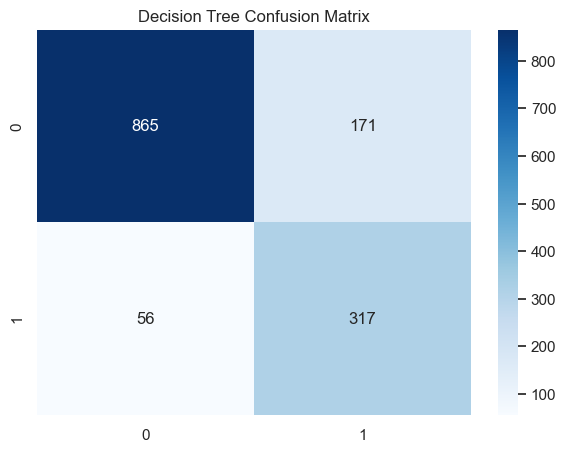

In [109]:
# Confusion Matrix

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, decision_tree_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.show()

In [110]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, decision_tree_pred)
print("Confusion Matrix\n", cm)
print("True Positive(TP): ", cm[0,0])
print("True Negative(TN): ", cm[1,1])
print("False Positive(FP): ",cm[0,1])
print("False Negative(FN): ", cm[1,0])

Confusion Matrix
 [[865 171]
 [ 56 317]]
True Positive(TP):  865
True Negative(TN):  317
False Positive(FP):  171
False Negative(FN):  56


In [111]:
#Declaring TP, TN, FP and FN
TP = cm[0,0]
TN = cm[1,1]
FP = cm[0,1]
FN = cm[1,0]

### Classification Metrics For Decision Tree

1. Classification Accuracy
2. Classification Error
3. Precision
4. Recall
5. F1 Score
6. True Positive Rate(TPR)
7. False Positive Rate(FPR)
8. Specificity

In [112]:
#Classification Accuracy
ca = (TP + TN) / float(TP + TN + FP + FN)
print("Classification Accuracy: {0:0.4f} ".format(ca))

#Classification Error
ce = (FP + FN) / float(TP + TN + FP + FN)
print("Classification Error: {0:0.4f} ".format(ce))

#Precision
precision = TP / float(TP + FP)
print("Precision Value: {0:0.4f}".format(precision))

#Recall
recall = TP / float(TP + FN)
print("Recall: {0:0.4f}".format(recall))

#F1_Score
from sklearn.metrics import f1_score
F1_Score = 2*(precision*recall) / (precision + recall)
print("F1 Score: {0:0.4f}".format(F1_Score))

true_positive_rate = TP / float(TP + FN)
print('True Positive Rate : {0:0.4f}'.format(true_positive_rate))

false_positive_rate = FP / float(FP + TN)
print('False Positive Rate : {0:0.4f}'.format(false_positive_rate))

specificity = TN / (TN + FP)
print('Specificity : {0:0.4f}'.format(specificity))

Classification Accuracy: 0.8389 
Classification Error: 0.1611 
Precision Value: 0.8349
Recall: 0.9392
F1 Score: 0.8840
True Positive Rate : 0.9392
False Positive Rate : 0.3504
Specificity : 0.6496


#### ROC - AOC Score For Decision Tree

Accuracy: 0.8388928317955997
Precision: 0.6495901639344263
Recall: 0.8498659517426274
F1-Score: 0.7363530778164924
ROC-AUC Score: 0.9102226029169729


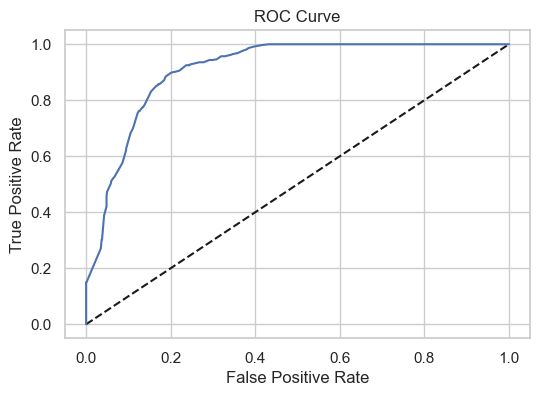

In [113]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve


accuracy = accuracy_score(y_test, decision_tree_pred)
precision = precision_score(y_test, decision_tree_pred)
recall = recall_score(y_test, decision_tree_pred)
f1 = f1_score(y_test, decision_tree_pred)
roc_auc = roc_auc_score(y_test, decision_tree.predict_proba(X_test)[:, 1])


print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1-Score:', f1)
print('ROC-AUC Score:', roc_auc)

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, decision_tree.predict_proba(X_test)[:, 1])
fig = plt.figure(figsize=(6, 4))
plt.plot([0, 1], [0, 1], 'k--')  # Plot the diagonal 50% line
plt.plot(fpr, tpr)  # Plot the FPR and TPR achieved by the model
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

### Building a model using Random Forest Algorithm

In [114]:
from sklearn.ensemble import RandomForestClassifier

# Create and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=200, min_samples_leaf = 1, min_samples_split = 2, random_state=42)
rf_model.fit(X_train_oversamp, y_train_oversamp)

RandomForestClassifier(n_estimators=200, random_state=42)

In [115]:
# Make predictions
rf_pred = rf_model.predict(X_test)

In [116]:
# Evaluate the model
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Accuracy: {rf_accuracy * 100:.2f}%")

Accuracy: 100.00%


In [117]:
# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1036
           1       1.00      1.00      1.00       373

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



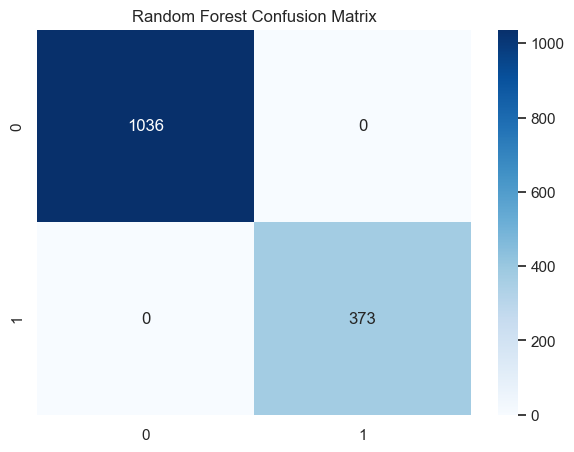

In [118]:
# Confusion Matrix

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.show()

### Classification Metrics For Random Forest

1. Classification Accuracy
2. Classification Error
3. Precision
4. Recall
5. F1 Score
6. True Positive Rate(TPR)
7. False Positive Rate(FPR)
8. Specificity

In [119]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, rf_pred)
print("Confusion Matrix\n", cm)
print("True Positive(TP): ", cm[0,0])
print("True Negative(TN): ", cm[1,1])
print("False Positive(FP): ",cm[0,1])
print("False Negative(FN): ", cm[1,0])

Confusion Matrix
 [[1036    0]
 [   0  373]]
True Positive(TP):  1036
True Negative(TN):  373
False Positive(FP):  0
False Negative(FN):  0


In [120]:
#Declaring TP, TN, FP and FN
TP = cm[0,0]
TN = cm[1,1]
FP = cm[0,1]
FN = cm[1,0]

In [121]:
#Classification Accuracy
ca = (TP + TN) / float(TP + TN + FP + FN)
print("Classification Accuracy: {0:0.4f} ".format(ca))

#Classification Error
ce = (FP + FN) / float(TP + TN + FP + FN)
print("Classification Error: {0:0.4f} ".format(ce))

#Precision
precision = TP / float(TP + FP)
print("Precision Value: {0:0.4f}".format(precision))

#Recall
recall = TP / float(TP + FN)
print("Recall: {0:0.4f}".format(recall))

#F1_Score
from sklearn.metrics import f1_score
F1_Score = 2*(precision*recall) / (precision + recall)
print("F1 Score: {0:0.4f}".format(F1_Score))

true_positive_rate = TP / float(TP + FN)
print('True Positive Rate : {0:0.4f}'.format(true_positive_rate))

false_positive_rate = FP / float(FP + TN)
print('False Positive Rate : {0:0.4f}'.format(false_positive_rate))

specificity = TN / (TN + FP)
print('Specificity : {0:0.4f}'.format(specificity))

Classification Accuracy: 1.0000 
Classification Error: 0.0000 
Precision Value: 1.0000
Recall: 1.0000
F1 Score: 1.0000
True Positive Rate : 1.0000
False Positive Rate : 0.0000
Specificity : 1.0000


#### ROC - AOC Score For Random Forest

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
ROC-AUC Score: 1.0


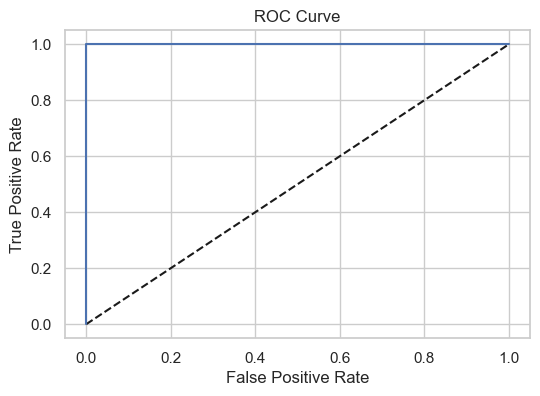

In [85]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve


accuracy = accuracy_score(y_test, rf_pred)
precision = precision_score(y_test, rf_pred)
recall = recall_score(y_test, rf_pred)
f1 = f1_score(y_test, rf_pred)
roc_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])


print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1-Score:', f1)
print('ROC-AUC Score:', roc_auc)

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, rf_model.predict_proba(X_test)[:, 1])
fig = plt.figure(figsize=(6, 4))
plt.plot([0, 1], [0, 1], 'k--')  # Plot the diagonal 50% line
plt.plot(fpr, tpr)  # Plot the FPR and TPR achieved by the model
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

### Model Comparison

In [122]:
# Summary of accuracies
model_accuracies = {
    'Logistic Regression': logreg_accuracy,
    'K-Nearest Neighbors': knn_accuracy,
    'Decision Tree': decision_tree_accuracy,
    'Random Forest': rf_accuracy,}

# Display accuracies
for model, accuracy in model_accuracies.items():
    print(f'{model} Accuracy: {accuracy*100:.2f} %')

Logistic Regression Accuracy: 76.86 %
K-Nearest Neighbors Accuracy: 79.42 %
Decision Tree Accuracy: 83.89 %
Random Forest Accuracy: 100.00 %


### Optimization in Machine Learning

In [89]:
# Import necessary libraries
from sklearn.model_selection import GridSearchCV

# --- Logistic Regression Optimization ---
logreg_param_grid = {
    'C': [0.1, 1, 10],  # Regularization parameter
    'solver': ['liblinear', 'lbfgs'],  # Solvers to use
    'max_iter': [100, 200, 300]  # Maximum number of iterations
}
logreg_grid_search = GridSearchCV(LogisticRegression(), logreg_param_grid, cv=5, scoring='accuracy')
logreg_grid_search.fit(X_train_oversamp, y_train_oversamp)
logreg_best_params = logreg_grid_search.best_params_
logreg_best_accuracy = logreg_grid_search.best_score_

In [90]:
# --- K-Nearest Neighbors Optimization ---
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 10],  # Number of neighbors
    'weights': ['uniform', 'distance'],  # Weight function used in prediction
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']  # Algorithm used to compute the nearest neighbors
}
knn_grid_search = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5, scoring='accuracy')
knn_grid_search.fit(X_train_oversamp, y_train_oversamp)
knn_best_params = knn_grid_search.best_params_
knn_best_accuracy = knn_grid_search.best_score_

In [91]:
# --- Decision Tree Optimization ---
decision_tree_param_grid = {
    'max_depth': [3, 5, 10, None],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],  # Minimum samples required to be at a leaf node
    'criterion': ['gini', 'entropy']  # Function to measure the quality of a split
}
decision_tree_grid_search = GridSearchCV(DecisionTreeClassifier(), decision_tree_param_grid, cv=5, scoring='accuracy')
decision_tree_grid_search.fit(X_train_oversamp, y_train_oversamp)
decision_tree_best_params = decision_tree_grid_search.best_params_
decision_tree_best_accuracy = decision_tree_grid_search.best_score_

In [93]:
# --- Random Forest Optimization ---
rf_param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [3, 5, 10, None],  # Maximum depth of each tree
    'min_samples_split': [2, 5, 10],  # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]  # Minimum samples required to be at a leaf node
}
rf_grid_search = GridSearchCV(RandomForestClassifier(), rf_param_grid, cv=5, scoring='accuracy')
rf_grid_search.fit(X_train_oversamp, y_train_oversamp)
rf_best_params = rf_grid_search.best_params_
rf_best_accuracy = rf_grid_search.best_score_

In [97]:
# --- Print results for all models ---
print("Hyperparameter Tuning for Logistic Regression: ")
print("Logistic Regression Best Params:", logreg_best_params)
print("Logistic Regression Best Accuracy:", logreg_best_accuracy)

print("\nHyperparameter Tuning for K-Nearest Neighbors: ")
print("K-Nearest Neighbors Best Params:", knn_best_params)
print("K-Nearest Neighbors Best Accuracy:", knn_best_accuracy)

print("\nHyperparameter Tuning for Decision Tree: ")
print("Decision Tree Best Params:", decision_tree_best_params)
print("Decision Tree Best Accuracy:", decision_tree_best_accuracy)

print("\nHyperparameter Tuning for Random Forest: ")
print("Random Forest Best Params:", rf_best_params)
print("Random Forest Best Accuracy:", rf_best_accuracy)

Hyperparameter Tuning for Logistic Regression: 
Logistic Regression Best Params: {'C': 1, 'max_iter': 100, 'solver': 'lbfgs'}
Logistic Regression Best Accuracy: 0.8034464594672214

Hyperparameter Tuning for K-Nearest Neighbors: 
K-Nearest Neighbors Best Params: {'algorithm': 'auto', 'n_neighbors': 3, 'weights': 'distance'}
K-Nearest Neighbors Best Accuracy: 0.7623705820683988

Hyperparameter Tuning for Decision Tree: 
Decision Tree Best Params: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}
Decision Tree Best Accuracy: 0.8049005447332721

Hyperparameter Tuning for Random Forest: 
Random Forest Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest Best Accuracy: 0.8431717345773706


## Model Performance

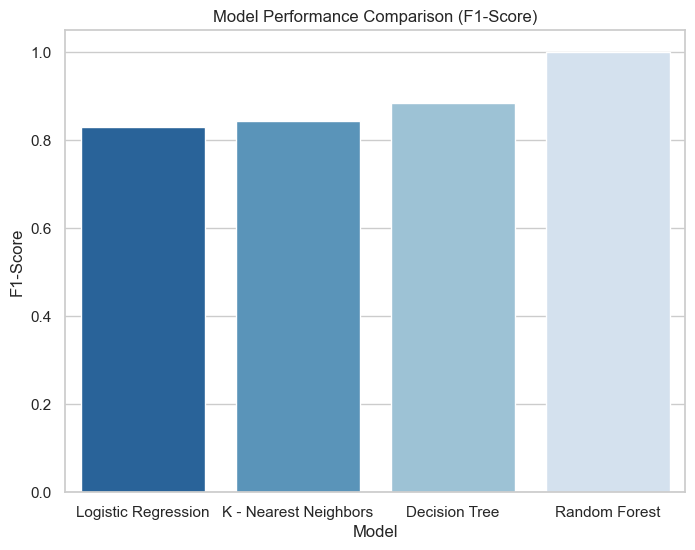

In [129]:
# Model Performance (Bar Chart - F1-Score)
plt.figure(figsize = (8,6))
results_data = pd.DataFrame({
    "Model": ["Logistic Regression", "K - Nearest Neighbors", "Decision Tree", "Random Forest"],
    "Accuracy": [0.80, 0.76, 0.80, 0.84],
    "Precision": [0.5437, 0.7606, 0.8349, 1.0000],
    "Recall": [0.9071, 0.9494, 0.9392, 1.0000],
    "F1-Score": [0.8291, 0.8446, 0.8840, 1.0000]
})

sns.barplot(x="Model", y="F1-Score", data=results_data, palette="Blues_r")
plt.title("Model Performance Comparison (F1-Score)")
plt.show()

### Feature Importance


Feature Importance:
Contract            0.132839
MonthlyCharges      0.120203
tenure              0.108667
TotalCharges        0.106878
customerID          0.092352
OnlineSecurity      0.082054
TechSupport         0.070638
OnlineBackup        0.039865
PaymentMethod       0.037392
InternetService     0.033551
DeviceProtection    0.029277
Dependents          0.025413
Partner             0.022202
gender              0.018857
MultipleLines       0.016770
StreamingTV         0.016050
StreamingMovies     0.015012
PaperlessBilling    0.014602
SeniorCitizen       0.011661
PhoneService        0.005718
dtype: float64


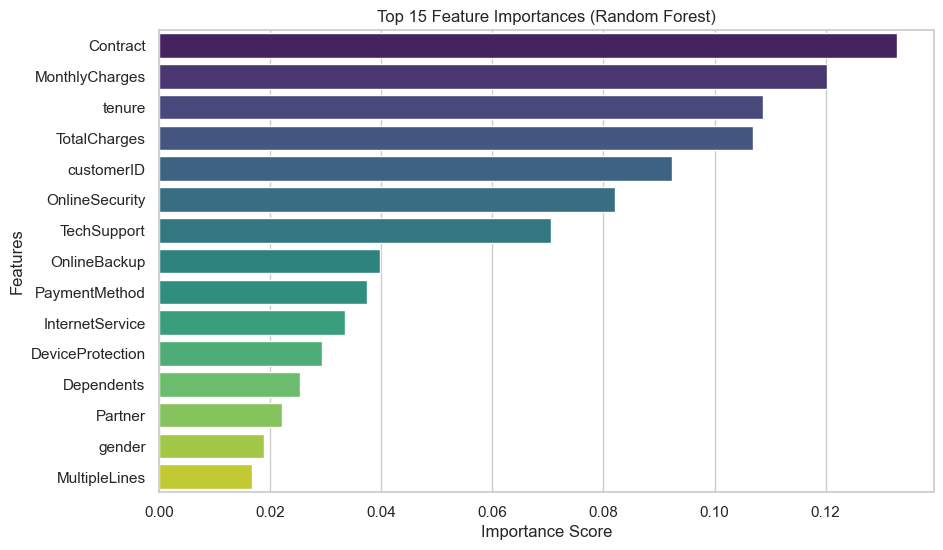

In [131]:
# Feature Importance

# Compute Feature Importance
feature_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Print Feature Importance
print("\nFeature Importance:")
print(feature_importance)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance[:15], y=feature_importance.index[:15], palette="viridis")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

### Predictions

In [137]:
# Choose a random row from X_test
my_features = X_test.iloc[np.random.randint(0, len(X_test))]
own_pred = rf_model.predict(my_features.to_numpy().reshape(1,-1))
print("My prediction is a {}.".format(own_pred[0]))
print("This was the input data:")
print(my_features)

My prediction is a 0.
This was the input data:
customerID          3384.0
gender                 1.0
SeniorCitizen          0.0
Partner                1.0
Dependents             1.0
tenure                50.0
PhoneService           1.0
MultipleLines          0.0
InternetService        1.0
OnlineSecurity         0.0
OnlineBackup           2.0
DeviceProtection       2.0
TechSupport            2.0
StreamingTV            2.0
StreamingMovies        2.0
Contract               1.0
PaperlessBilling       1.0
PaymentMethod          0.0
MonthlyCharges       103.4
TotalCharges        5236.4
Name: 6639, dtype: float64


## Conclusion:
#### Customer Behavior & Churn Trends
1. Customers with higher monthly charges tend to have a higher churn rate.
2. Customers with longer tenure (more months of service) are less likely to churn.
3. Contract Type plays a major role—customers on month-to-month contracts churn more than those with annual or two-year contracts.
4. Paperless billing and Electronic Payment Methods are associated with a higher churn rate.
5. Customers with DSL and Fiber Optic internet services tend to show different churn patterns, with Fiber Optic customers having a slightly higher churn rate.


## Business Implications & Recommendations
#### Customer Retention Strategies:

1. Focus on reducing churn in high-risk segments, such as customers on month-to-month contracts.
2. Provide discounts or loyalty incentives for long-term contracts.
3. Target customers with high monthly charges with special offers.

#### Billing & Payment Adjustments:

1. Customers using paperless billing and electronic payments tend to churn more, so provide better user experience, discounts, or alternative payment options.
2. Improving Internet Services: Customers with Fiber Optic services show slightly higher churn rates. Ensure quality of service, fast issue resolution, and targeted customer support.
3. Enhancing Customer Support Customers with higher call center interactions may indicate dissatisfaction. Improving customer service experience and response times can help reduce churn.
